# Earth Gravity Work

This notebook illustrates the work done when moving through Earth's gravitational field. Gravity is radial, so only the radial part of the displacement contributes to $dW = \vec{F}\cdot\vec{ds}$.

The examples below compare several paths from the same starting point $P_0$ on Earth's surface to the same endpoint $P_1$ in a high orbit. The paths look different, but the total work done by gravity is the same because the gravitational field is conservative.

(Click {fa}`rocket` --> {guilabel}`Live Code` to activate live code on this page.)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

G = 6.67430e-11       # gravitational constant, m^3 kg^-1 s^-2
M_E = 5.972e24        # Earth mass, kg
R_E = 6.371e6         # Earth radius, m
g0 = G * M_E / R_E**2 # surface gravity, m s^-2

r_start = R_E
r_end = 2.0 * R_E       # high orbit, comparable to Earth's radius
r_overshoot = 2.45 * R_E # one path climbs too high, then comes back
theta_start = 0.0
theta_end = np.deg2rad(70)

def gravity_acceleration(x, y):
    r = np.sqrt(x**2 + y**2)
    return -G * M_E * x / r**3, -G * M_E * y / r**3

def make_path(kind, n=500):
    t = np.linspace(0, 1, n)
    if kind == "out_then_around":
        halfway = t < 0.5
        r = np.empty_like(t)
        theta = np.empty_like(t)
        r[halfway] = r_start + (r_end - r_start) * t[halfway] / 0.5
        theta[halfway] = theta_start
        r[~halfway] = r_end
        theta[~halfway] = theta_start + (theta_end - theta_start) * (t[~halfway] - 0.5) / 0.5
    elif kind == "spiral":
        r = r_start + (r_end - r_start) * t
        theta = theta_start + (theta_end - theta_start) * t
    elif kind == "around_then_out":
        halfway = t < 0.5
        r = np.empty_like(t)
        theta = np.empty_like(t)
        r[halfway] = r_start
        theta[halfway] = theta_start + (theta_end - theta_start) * t[halfway] / 0.5
        r[~halfway] = r_start + (r_end - r_start) * (t[~halfway] - 0.5) / 0.5
        theta[~halfway] = theta_end
    elif kind == "overshoot_then_return":
        turn = 0.65
        outbound = t < turn
        r = np.empty_like(t)
        theta = np.empty_like(t)
        r[outbound] = r_start + (r_overshoot - r_start) * t[outbound] / turn
        theta[outbound] = theta_start + 0.75 * (theta_end - theta_start) * t[outbound] / turn
        r[~outbound] = r_overshoot + (r_end - r_overshoot) * (t[~outbound] - turn) / (1 - turn)
        theta[~outbound] = theta_start + 0.75 * (theta_end - theta_start) + 0.25 * (theta_end - theta_start) * (t[~outbound] - turn) / (1 - turn)
    else:
        raise ValueError(f"Unknown path kind: {kind}")

    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y

def cumulative_gravity_work(x, y):
    dx = np.diff(x)
    dy = np.diff(y)
    xm = 0.5 * (x[:-1] + x[1:])
    ym = 0.5 * (y[:-1] + y[1:])
    gx, gy = gravity_acceleration(xm, ym)
    dW_per_kg = gx * dx + gy * dy
    return np.concatenate([[0], np.cumsum(dW_per_kg)])

paths = {
    "out then around": make_path("out_then_around"),
    "spiral": make_path("spiral"),
    "around then out": make_path("around_then_out"),
    "overshoot then return": make_path("overshoot_then_return"),
}

analytic_work_per_kg = G * M_E * (1/r_end - 1/r_start)
print(f"Analytic work done by gravity: {analytic_work_per_kg:.3e} J/kg")
print(f"External work required: {-analytic_work_per_kg:.3e} J/kg")

Analytic work done by gravity: -3.128e+07 J/kg
External work required: 3.128e+07 J/kg


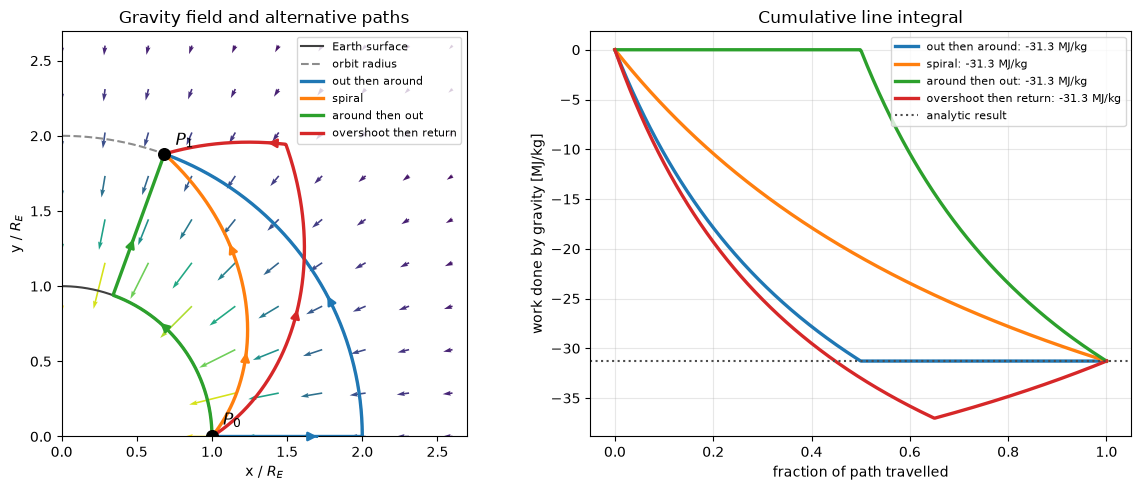

In [2]:
fig, (ax_field, ax_work) = plt.subplots(1, 2, figsize=(12, 5))

# Gravity field, shown in Earth-radius units. The arrows point inward and
# become shorter farther from Earth because |g| decreases as 1/r^2.
grid = np.linspace(-2.6, 2.6, 19)
X, Y = np.meshgrid(grid, grid)
radius = np.sqrt(X**2 + Y**2)
mask = radius > 1.05

x_m = X[mask] * R_E
y_m = Y[mask] * R_E
gx, gy = gravity_acceleration(x_m, y_m)

ax_field.quiver(
    X[mask], Y[mask], gx/g0, gy/g0,
    np.sqrt(gx**2 + gy**2)/g0,
    cmap="viridis", scale=6, width=0.004
)

theta = np.linspace(0, 2*np.pi, 500)
ax_field.plot(np.cos(theta), np.sin(theta), color="0.25", label="Earth surface")
ax_field.plot(2*np.cos(theta), 2*np.sin(theta), "--", color="0.55", label="orbit radius")

def add_path_arrows(ax, x, y, color, fractions=(0.35, 0.7)):
    for fraction in fractions:
        i = int(fraction * (len(x) - 2))
        ax.annotate(
            "",
            xy=(x[i + 1]/R_E, y[i + 1]/R_E),
            xytext=(x[i]/R_E, y[i]/R_E),
            arrowprops={"arrowstyle": "-|>", "color": color, "lw": 1.8, "mutation_scale": 13},
        )

p0_x = r_start * np.cos(theta_start) / R_E
p0_y = r_start * np.sin(theta_start) / R_E
p1_x = r_end * np.cos(theta_end) / R_E
p1_y = r_end * np.sin(theta_end) / R_E

ax_field.scatter([p0_x, p1_x], [p0_y, p1_y], s=70, color="black", zorder=5)
ax_field.annotate("$P_0$", (p0_x, p0_y), xytext=(8, 8), textcoords="offset points", fontsize=12, weight="bold")
ax_field.annotate("$P_1$", (p1_x, p1_y), xytext=(8, 6), textcoords="offset points", fontsize=12, weight="bold")

for label, (x, y) in paths.items():
    line, = ax_field.plot(x/R_E, y/R_E, linewidth=2.4, label=label)
    add_path_arrows(ax_field, x, y, line.get_color())
    work = cumulative_gravity_work(x, y)
    progress = np.linspace(0, 1, len(work))
    ax_work.plot(progress, work/1e6, linewidth=2.4, label=f"{label}: {work[-1]/1e6:.1f} MJ/kg")

ax_work.axhline(analytic_work_per_kg/1e6, color="0.3", linestyle=":", label="analytic result")

ax_field.set_aspect("equal")
plot_limit = 1.1 * r_overshoot / R_E
ax_field.set_xlim(0, plot_limit)
ax_field.set_ylim(0, plot_limit)
ax_field.set_xlabel("x / $R_E$")
ax_field.set_ylabel("y / $R_E$")
ax_field.set_title("Gravity field and alternative paths")
ax_field.legend(loc="upper right", fontsize=8)

ax_work.set_xlabel("fraction of path travelled")
ax_work.set_ylabel("work done by gravity [MJ/kg]")
ax_work.set_title("Cumulative line integral")
ax_work.legend(fontsize=8)
ax_work.grid(True, alpha=0.3)

plt.tight_layout()

# Save the default figure so it can be reused from the Markdown chapter.
cwd = Path.cwd()
if cwd.name == "introduction":
    figure_dir = cwd / "figures"
elif cwd.name == "2_potential_fields":
    figure_dir = cwd / "introduction" / "figures"
elif (cwd / "2_potential_fields").exists():
    figure_dir = cwd / "2_potential_fields" / "introduction" / "figures"
else:
    figure_dir = cwd / "book" / "2_potential_fields" / "introduction" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_dir / "earth_gravity_work.png", dpi=200, bbox_inches="tight")

plt.show()

Try changing `r_end`, `theta_end`, or the path definitions above. As long as the starting and ending points are unchanged, the total gravitational work is unchanged. The overshoot path climbs beyond $P_1$, so gravity does extra negative work at first; when the path returns inward, gravity does positive work and the cumulative integral recovers to the same final value.